In [ ]:
import numpy as np
from pathlib import Path

import geopandas as gpd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.crs import Geodetic
from cartopy.feature import LAND, COASTLINE

import warnings

warnings.simplefilter("ignore")

In [ ]:
# Parameters
base_path = "/gxfs_work/geomar/smomw597/2025_Fucus"

In [ ]:
base_path = Path(base_path)
repo_path = base_path

In [ ]:
release_area_path = Path(repo_path, "data/Fucus_location_shp")
release_area_file = Path(release_area_path, "REDLIST_SIS_Macrophytes.shp")

gdf_release_area = gpd.read_file(release_area_file)
gdf_release_area = gdf_release_area.assign(CELLID=gdf_release_area.index.astype(int))
gdf_release_area = gdf_release_area.to_crs(crs=Geodetic())
gdf_release_area.to_file(Path(release_area_path,"REDLIST_SIS_Macrophytes.geojson"), driver="GeoJSON")

In [ ]:
subbasins_lvl2_path = Path(repo_path, "HELCOM_subbasins_2022_level2")
subbasins_lvl2_file = Path(subbasins_lvl2_path, "HELCOM_subbasins_2022_level2.shp")

gdf_subbasins_area = gpd.read_file(subbasins_lvl2_file)

# gdf_release_area = gdf_release_area.assign(CELLID=gdf_release_area.index.astype(int))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=Geodetic())
gdf_subbasins_area.to_file(Path(subbasins_lvl2_path,"HELCOM_subbasins_2022_level2.geojson"), driver="GeoJSON")

# Schleswig-Holstein coast

In [ ]:
administrative_borders = gpd.read_file(Path(repo_path, "Administrative_boundaries/Administrative_boundaries.shp")).to_crs(crs=ccrs.Geodetic())
sh_border = administrative_borders.set_index("NAME").loc[["Schleswig-Holstein"]]

<Axes: >

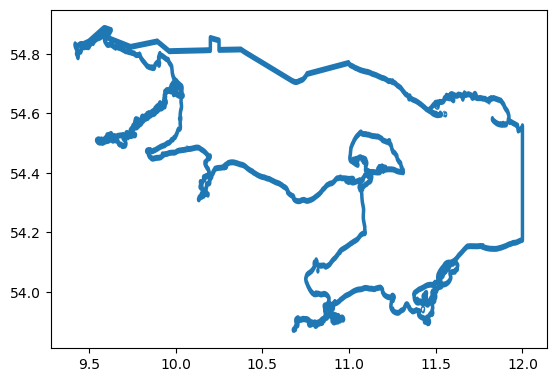

In [140]:
gdf_baltic = gdf_subbasins_area.clip(mask=(0,0,12,55)).cx[:11.5, :54.6].dissolve()
coast_region_radius_deg = .01
gdf_baltic_unbuffed = gdf_baltic.buffer(coast_region_radius_deg).buffer(-coast_region_radius_deg)
gdf_baltic_coast = gdf_baltic.boundary.buffer(coast_region_radius_deg)
gdf_baltic_coast.plot()

In [ ]:
gdf_baltic_buffed = gdf_baltic.buffer(.2)
sh_coast = (
        sh_border
        .boundary
        .clip(gdf_baltic_buffed)
        .explode()
)
sh_coast.plot()

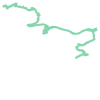

In [212]:
sh_coast[1]

In [222]:
import shapely
from shapely.ops import split
sh_main_coast = sh_coast[1].difference(administrative_borders.cx[10:11,53.5:55].dissolve().buffer(-.001))[0]

splitlines = shapely.MultiLineString([
                ((10.8,54.14),(10.82,54.04)),
                ((11.11,54.38),(11.25,54.52)),
                ((10.3,54.4), (10.3,54.5)),
                ((9.9,54.53),(10.1,54.55)),
                ((9.9,54.7),(10,54.8)),
                ((10,54.4),(10.2,54.5)),
])
sh_coast_split = gpd.GeoDataFrame(
        dict(
                names=["Flensburger Foerde", "Schleimuendung", "Eckernfoerde","Kieler Foerde","Kieler Bucht","Mecklenburger Bucht","Luebecker Bucht", "Fehmarn"], 
                geometry=np.append(shapely.get_parts(split(sh_main_coast, splitlines)), sh_coast.geometry[0]),
        ),
        # crs=ccrs.Geodetic()
).explode().reset_index(drop=True).set_index("names")

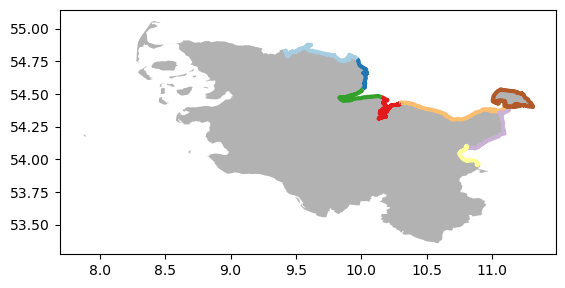

In [227]:
fig, ax = plt.subplots()
# administrative_borders.cx[9:11,53:55].dissolve().plot(ax=ax)
sh_border.to_crs(crs=ccrs.Geodetic()).plot(ax=ax, alpha=.6, color="gray")
sh_coast_split.plot(cmap="Paired", ax=ax, lw=3)
# ax.set_xlim((10.5,11))
# ax.set_ylim((53.5,54))
# sh_release_areas.plot(ax=ax)
plt.show()

In [ ]:
output_path = Path(repo_path, "output/SamplePoints")

In [ ]:
sh_coast_split.to_file(Path(output_path, "sh_baltic_coast_split.geojson"), driver="GeoJSON")

In [ ]:
working_directory = Path(repo_path, "data/Fucus_location_shp")
location_file = Path(working_directory, "REDLIST_SIS_Macrophytes.shp")
# location_file = "zip://gxfs_work/geomar/smomw597/2025_Fucus/REDLIST_SIS_Macrophytes.zip!data"
fucus_locations = gpd.read_file(location_file)

In [3]:
# fucus_locations[fucus_locations.where(fucus_locations !=0)]#.plot()
location_columns = np.delete(fucus_locations.columns.values, [0, 10, 25, 26])
fucus_locations = fucus_locations.drop(labels=location_columns, axis=1)

In [ ]:
fucus_locations = fucus_locations.drop(fucus_locations[fucus_locations.F_vesiculo ==0].index).to_crs(crs=ccrs.Geodetic())

In [5]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (9, 29, 52, 64)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = ccrs.Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

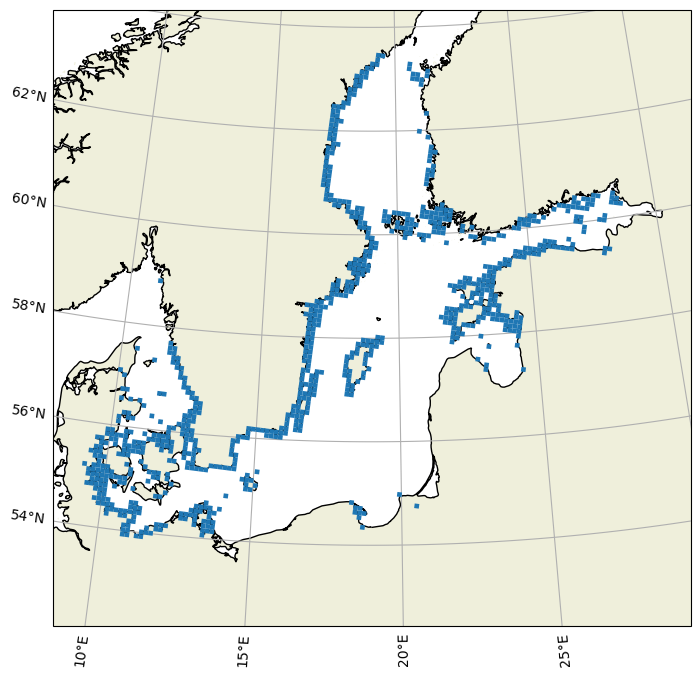

In [11]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
fucus_locations.to_crs(crs=map_projection).plot(ax = ax_map, zorder=5, )
map_extent = ax_map.get_extent(crs=map_projection)
plt.show()